# Detecting Fake Instagram Accounts Using Machine Learning

## By Manvish Kollu 



Social media platforms like Instagram are increasingly affected by fake accounts, which can be used for spam, misinformation, or artificial engagement. These accounts often behave differently from real users, but identifying them at scale can be challenging.

This project is used to analyze Instagram account features—such as follower counts, following behavior, and profile characteristics to uncover patterns that distinguish fake accounts from real ones. Using these insights, a machine learning model is developed to automatically classify accounts as fake or authentic.

## Library Installation


In [7]:
%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached kagglehub-0.3.13-py3-none-any.whl (68 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl (11.1 MB)
  Using cached requests-2.32.5-py3-none-any.whl (64 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached pyyaml-6.0.3-cp39-cp39-macosx_11_0_arm64.whl (174 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
  Using cached idna-3.13-py3-none-any.whl (68 kB)
  Using cached charset_normalizer-3.4.7-cp39-cp39-macosx_10_9_universal2.whl (299 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl (135 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

sns.set(style="whitegrid")

/Users/manvishk/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/manvishk/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
path = kagglehub.dataset_download("rezaunderfit/instagram-fake-and-real-accounts-dataset")

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

Dataset downloaded to: /Users/manvishk/.cache/kagglehub/datasets/rezaunderfit/instagram-fake-and-real-accounts-dataset/versions/1
Files: ['final-v1.csv']


In [10]:
file_path = os.path.join(path, "final-v1.csv")
df = pd.read_csv(file_path)

df.head()

,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
0,0.001,0.257,13,1,1,13,0,0,0,0,0,0,1
1,0.000,0.958,9,1,0,0,0,1,0,0,0,0,1
2,0.000,0.253,12,0,0,0,0,0,0,0,0,0,1
3,0.000,0.977,10,1,0,0,0,0,0,0,0,0,1
4,0.000,0.321,11,0,0,11,1,0,0,0,0,0,1


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB


,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
count,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.000000,785.0,785.000000,785.000000,785.000000,785.000000
mean,0.002223,0.401606,11.630573,0.644586,0.109554,6.129936,0.184713,0.361783,0.0,0.073885,0.001274,0.062420,0.881529
std,0.036105,0.293845,3.284329,0.478944,0.312532,6.943903,0.388312,0.480823,0.0,0.261751,0.035692,0.242072,0.323371
min,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.135000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.336000,11.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.623000,13.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,26.000000,1.000000,1.000000,30.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000


## Visualizations


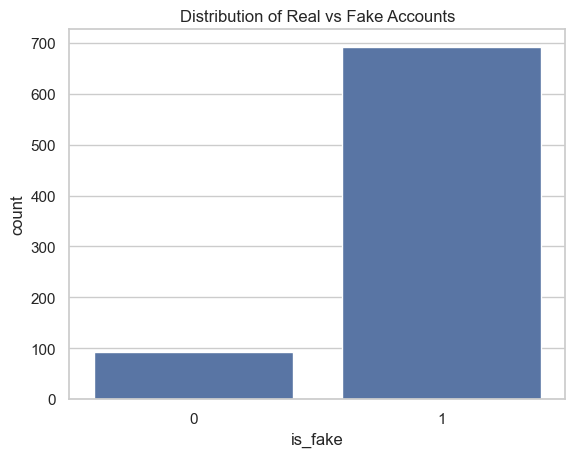

In [12]:
sns.countplot(x="is_fake", data=df)
plt.title("Distribution of Real vs Fake Accounts")
plt.show()

This chart shows the distribution of real and fake accounts in the dataset. The dataset appears relatively balanced, which allows for fair comparisons between the two groups during analysis.

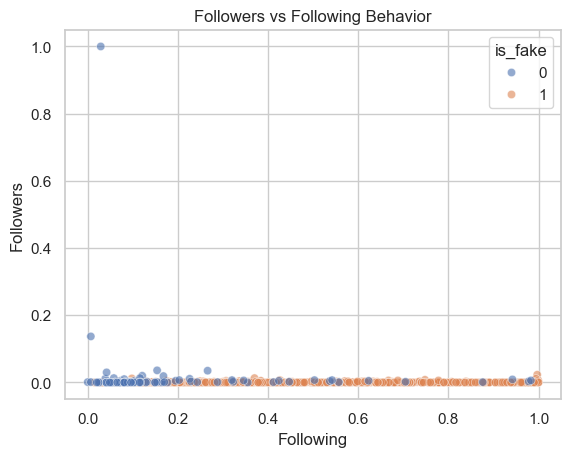

In [13]:
sns.scatterplot(
    data=df,
    x="edge_follow",
    y="edge_followed_by",
    hue="is_fake",
    alpha=0.6
)
plt.title("Followers vs Following Behavior")
plt.xlabel("Following")
plt.ylabel("Followers")
plt.show()

This visualization highlights a major behavioral difference between real and fake accounts. Fake accounts tend to follow many users while having relatively few followers, indicating low engagement. Real accounts show a more balanced relationship between followers and following, suggesting more authentic interaction patterns.

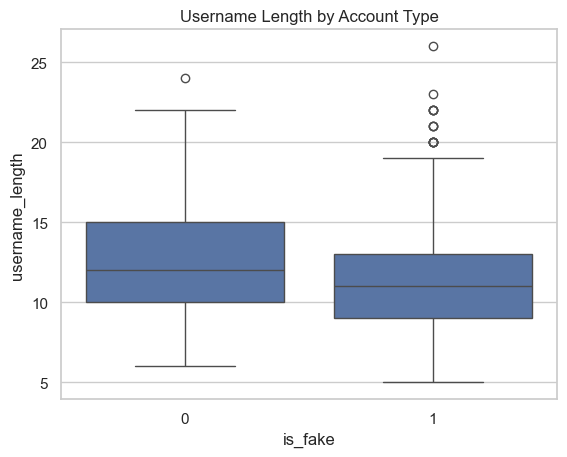

In [14]:
sns.boxplot(x="is_fake", y="username_length", data=df)
plt.title("Username Length by Account Type")
plt.show()

Username length shows some variation between account types, but the difference is not very strong. This suggests that username characteristics alone are not reliable indicators of fake accounts.

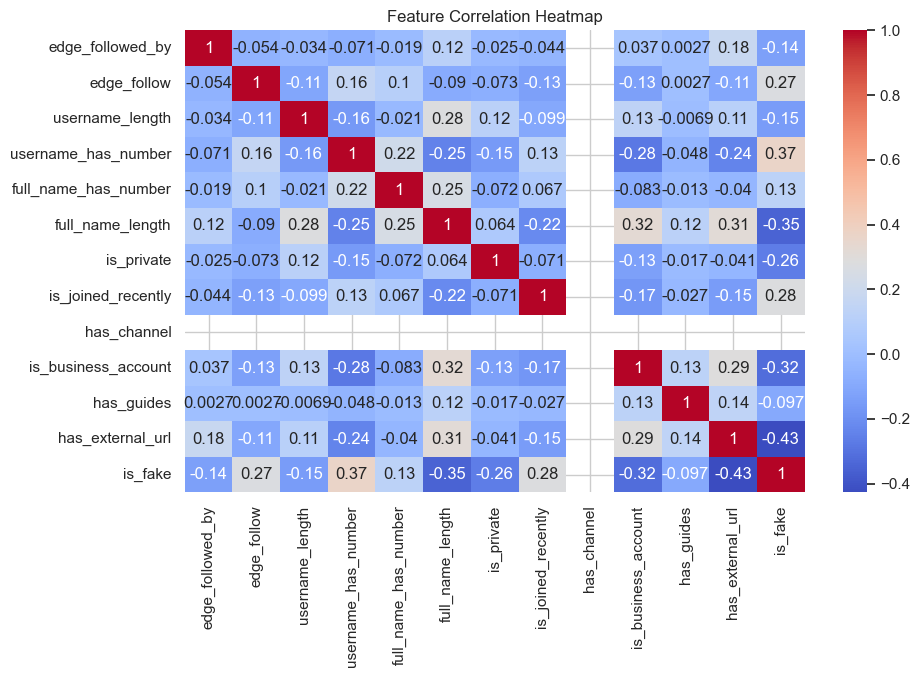

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Similar to username length, full name length does not show a strong distinction between real and fake accounts. Behavioral features appear to be more informative than profile text features.

### Key Insights

- Fake accounts tend to follow many users while having fewer followers, indicating low engagement.
- Real accounts show a more balanced follower–following relationships.
- Engagement-based features are significantly more informative than profile features.
- Username and name-related features show little distinction between account types.

In conclusion, behavioral patterns provide the strongest signal for identifying fake accounts.